In [2]:
%pip install pandas numpy statsmodels matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 2.9 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.7 MB 3.5 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.7 MB 3.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.7 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 4.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.7 MB 4.7 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.7 MB 4.4 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.7 MB 4.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
! pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 2.2 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.0 MB 3.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.0 MB 3.2 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.0 MB 2.6 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/8.0 MB 2.6 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.0 MB 2.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 2.6 M


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

### Phase 1: Data Setup & Power Analysis

In [ ]:
# 1. Load the separate datasets (FIXED: added sep=';')
control_df = pd.read_csv('../data/control_group.csv', sep=';')
treatment_df = pd.read_csv('../data/test_group.csv', sep=';')

# 2. Add group labels
control_df['group'] = 'control'
treatment_df['group'] = 'treatment'

# 3. Combine and clean
df_clean = pd.concat([control_df, treatment_df], ignore_index=True)
df_clean = df_clean.dropna(how='all')

print(f"Total Rows: {df_clean.shape[0]}")
print("Actual Columns:", df_clean.columns.tolist())

# --- METRIC CALCULATION ---
# For aggregated data, Sample Size = Total Clicks, Successes = Total Purchases
control_clicks = df_clean[df_clean['group'] == 'control']['# of Website Clicks'].sum()
control_purchases = df_clean[df_clean['group'] == 'control']['# of Purchase'].sum()

treatment_clicks = df_clean[df_clean['group'] == 'treatment']['# of Website Clicks'].sum()
treatment_purchases = df_clean[df_clean['group'] == 'treatment']['# of Purchase'].sum()

baseline_conversion = control_purchases / control_clicks
treatment_conversion = treatment_purchases / treatment_clicks

print(f"\n--- Metrics ---")
print(f"Control Conversion Rate: {baseline_conversion:.4f} ({baseline_conversion*100:.2f}%)")
print(f"Treatment Conversion Rate: {treatment_conversion:.4f} ({treatment_conversion*100:.2f}%)")

# --- POWER ANALYSIS ---
mde_absolute = 0.02 # 2% absolute lift
expected_treatment_rate = baseline_conversion + mde_absolute

effect_size = sms.proportion_effectsize(baseline_conversion, expected_treatment_rate)

required_n = sms.NormalIndPower().solve_power(
    effect_size, 
    power=0.80, 
    alpha=0.05, 
    ratio=1
)

required_n = int(np.ceil(required_n))

print(f"\n--- Power Analysis ---")
print(f"Required Sample Size (Clicks per group): {required_n}")
print(f"Actual Sample Size (Control Clicks): {int(control_clicks)}")

if control_clicks >= required_n:
    print("✅ Status: The dataset is sufficiently powered based on total clicks.")
else:
    print("⚠️ Status: The dataset is UNDERPOWERED for a 2% lift.")

Total Rows: 60
Actual Columns: ['Campaign Name', 'Date', 'Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks', '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase', 'group']

--- Metrics ---
Control Conversion Rate: 0.0983 (9.83%)
Treatment Conversion Rate: 0.0864 (8.64%)

--- Power Analysis ---
Required Sample Size (Clicks per group): 3781
Actual Sample Size (Control Clicks): 154303
✅ Status: The dataset is sufficiently powered based on total clicks.


### Phase 2: Statistical A/B Test Analysis

In [4]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# 1. Prepare the data arrays for the Z-Test
# We want to compare Treatment vs. Control
successes = np.array([treatment_purchases, control_purchases])
trials = np.array([treatment_clicks, control_clicks])

# 2. Perform the Two-Proportion Z-Test
# 'two-sided' checks if there is a difference in either direction (positive or negative)
z_stat, p_value = proportions_ztest(count=successes, nobs=trials, alternative='two-sided')

# 3. Calculate Confidence Intervals for the difference (Treatment - Control)
ci_low, ci_upp = confint_proportions_2indep(
    treatment_purchases, treatment_clicks, 
    control_purchases, control_clicks, 
    method='wald', compare='diff'
)

# 4. Calculate Lift Metrics
absolute_lift = treatment_conversion - baseline_conversion
relative_lift = absolute_lift / baseline_conversion

# 5. Output the Results
print("=== Phase 2: A/B Test Statistical Analysis ===")
print(f"Absolute Lift: {absolute_lift:.4f} ({absolute_lift*100:.2f}%)")
print(f"Relative Lift: {relative_lift:.4f} ({relative_lift*100:.2f}%)\n")

print("--- Statistical Significance ---")
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value:     {p_value:.6f}") # Using 6 decimals as massive sample sizes often have tiny p-values
print(f"95% Confidence Interval for Difference: [{ci_low:.4f}, {ci_upp:.4f}]\n")

# 6. Automated Conclusion
alpha = 0.05
if p_value < alpha:
    print("🎯 Conclusion: The result is STATISTICALLY SIGNIFICANT.")
    if absolute_lift > 0:
        print("Outcome: The treatment campaign was a SUCCESS.")
    else:
        print("Outcome: The treatment campaign had a NEGATIVE impact compared to the control.")
else:
    print("🤷‍♂️ Conclusion: The result is NOT statistically significant. We cannot confidently say the treatment had an effect.")

=== Phase 2: A/B Test Statistical Analysis ===
Absolute Lift: -0.0118 (-1.18%)
Relative Lift: -0.1206 (-12.06%)

--- Statistical Significance ---
Z-Statistic: -11.8387
P-Value:     0.000000
95% Confidence Interval for Difference: [-0.0138, -0.0099]

🎯 Conclusion: The result is STATISTICALLY SIGNIFICANT.
Outcome: The treatment campaign had a NEGATIVE impact compared to the control.


### Phase 3: Uplift Modeling (The T-Learner)

=== Phase 3: Uplift Modeling (T-Learner) ===
Generated 20000 user profiles.

--- Top 5 'Persuadable' Users (Target these!) ---
       age  past_purchases  website_visits_last_month  uplift_score
10331   33               2                          2      0.326992
16289   33               3                          3      0.296262
8474    21               2                          2      0.277306
7704    22               3                          2      0.253559
4411    23               3                          3      0.251261

--- Bottom 5 'Sleeping Dog' Users (Do NOT target these!) ---
       age  past_purchases  website_visits_last_month  uplift_score
18955   61               7                          6     -0.256241
7691    61               7                          6     -0.256241
10154   59               8                          4     -0.293344
1705    45               5                         24     -0.300357
18842   61               8                          6     -0.33

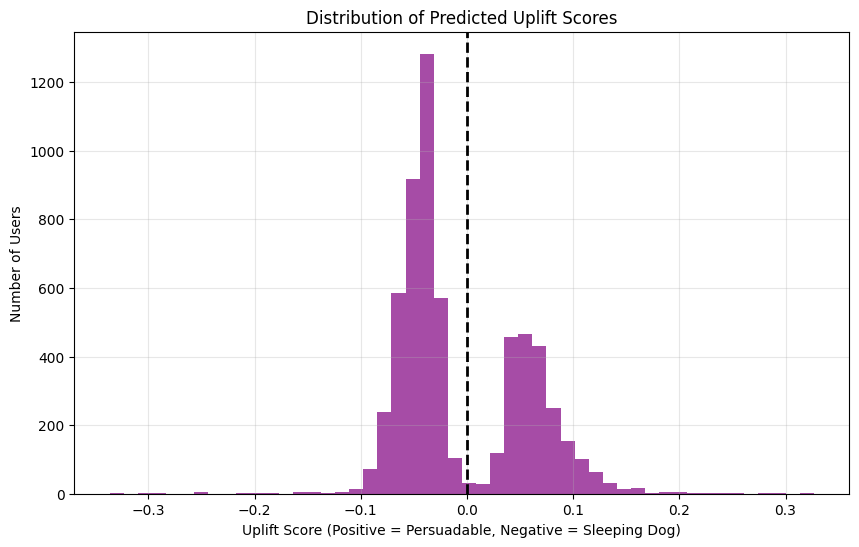

In [8]:
print("=== Phase 3: Uplift Modeling (T-Learner) ===")

# 1. Generate Synthetic User-Level Data (Since our Kaggle data was aggregated)
np.random.seed(42)
n_users = 20000

# Create user features
df_users = pd.DataFrame({
    'user_id': range(n_users),
    'age': np.random.randint(18, 65, n_users),
    'past_purchases': np.random.poisson(3, n_users),
    'website_visits_last_month': np.random.poisson(10, n_users),
    'is_treatment': np.random.binomial(1, 0.5, n_users) # 50/50 split
})

# Simulate a scenario: Treatment works GREAT for young people with past purchases, 
# but works TERRIBLY for older people (dragging the average down).
base_prob = 0.10 + (df_users['past_purchases'] * 0.01)
treatment_effect = np.where(df_users['age'] < 35, 0.08, -0.05) 

# Calculate final conversion probabilities and outcomes
final_prob = base_prob + (df_users['is_treatment'] * treatment_effect)
final_prob = np.clip(final_prob, 0, 1) # Keep probabilities between 0 and 1
df_users['converted'] = np.random.binomial(1, final_prob)

print(f"Generated {n_users} user profiles.")

# 2. Prepare Data for Modeling
features = ['age', 'past_purchases', 'website_visits_last_month']
X = df_users[features]
y = df_users['converted']
treatment = df_users['is_treatment']

# Train/Test Split
X_train, X_test, y_train, y_test, treat_train, treat_test = train_test_split(
    X, y, treatment, test_size=0.3, random_state=42
)

# 3. Build the T-Learner (Two Models)
# Model 1: Trained ONLY on Control Data
X_train_control = X_train[treat_train == 0]
y_train_control = y_train[treat_train == 0]
model_control = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_control.fit(X_train_control, y_train_control)

# Model 2: Trained ONLY on Treatment Data
X_train_treatment = X_train[treat_train == 1]
y_train_treatment = y_train[treat_train == 1]
model_treatment = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_treatment.fit(X_train_treatment, y_train_treatment)

# 4. Predict Uplift on the Test Set
# Predict probability of conversion if they WERE in control
pred_control = model_control.predict_proba(X_test)[:, 1]

# Predict probability of conversion if they WERE in treatment
pred_treatment = model_treatment.predict_proba(X_test)[:, 1]

# The magic formula: Uplift = P(Treatment) - P(Control)
uplift_scores = pred_treatment - pred_control

# 5. Attach scores back to test data to identify our segments
results_df = X_test.copy()
results_df['uplift_score'] = uplift_scores

# Sort users by highest uplift score (The "Persuadables")
results_df = results_df.sort_values(by='uplift_score', ascending=False)

print("\n--- Top 5 'Persuadable' Users (Target these!) ---")
print(results_df.head())

print("\n--- Bottom 5 'Sleeping Dog' Users (Do NOT target these!) ---")
print(results_df.tail())

# 6. Visualize the Distribution of Uplift Scores
plt.figure(figsize=(10, 6))
plt.hist(uplift_scores, bins=50, color='purple', alpha=0.7)
plt.axvline(0, color='black', linestyle='dashed', linewidth=2)
plt.title('Distribution of Predicted Uplift Scores')
plt.xlabel('Uplift Score (Positive = Persuadable, Negative = Sleeping Dog)')
plt.ylabel('Number of Users')
plt.grid(True, alpha=0.3)
plt.show()